In [33]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("day22_cleandata.csv",encoding="latin1")

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      500 non-null    object 
 1   Category      500 non-null    object 
 2   Sub-Category  500 non-null    object 
 3   Sales         500 non-null    float64
 4   Profit        500 non-null    float64
 5   Quantity      500 non-null    int64  
 6   Discount      500 non-null    float64
 7   Region        500 non-null    object 
 8   Order Date    500 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 35.3+ KB


In [35]:
df.dtypes

Order ID         object
Category         object
Sub-Category     object
Sales           float64
Profit          float64
Quantity          int64
Discount        float64
Region           object
Order Date       object
dtype: object

In [36]:
df.describe()

,Sales,Profit,Quantity,Discount
count,500.000000,500.000000,500.000000,500.000000
mean,1049.947180,146.071240,5.060000,0.249300
std,565.599141,191.263935,2.505385,0.147167
min,50.460000,-199.770000,1.000000,0.000000
25%,568.297500,-22.337500,3.000000,0.120000
50%,1068.830000,157.820000,5.000000,0.260000
75%,1553.197500,300.547500,7.000000,0.380000
max,1998.740000,496.840000,9.000000,0.500000


In [37]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [38]:
df.isnull().sum()

Order ID        0
Category        0
Sub-Category    0
Sales           0
Profit          0
Quantity        0
Discount        0
Region          0
Order Date      0
dtype: int64

In [39]:
df = df.drop_duplicates()

In [40]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          170596.50
Office Supplies    179467.34
Technology         174909.75
Name: Sales, dtype: float64

In [41]:
df.groupby("Region")["Profit"].mean()

Region
Central    166.390171
East       117.326692
South      146.757594
West       156.639500
Name: Profit, dtype: float64

In [42]:
df.groupby("Sub-Category")["Profit"].sum().sort_values()

Sub-Category
Phones     11826.74
Binders    13378.24
Tables     13421.53
Storage    16934.83
Chairs     17474.28
Name: Profit, dtype: float64

In [43]:
df[df["Sales"] > 1500]

,Order ID,Category,Sub-Category,Sales,Profit,Quantity,Discount,Region,Order Date
3,ORD-1003,Technology,Tables,1820.34,407.69,7,0.16,West,2023-01-04
9,ORD-1009,Technology,Chairs,1804.35,-57.41,6,0.04,East,2023-01-10
25,ORD-1025,Furniture,Chairs,1763.33,190.89,5,0.44,West,2023-01-26
29,ORD-1029,Technology,Phones,1995.50,28.15,2,0.19,East,2023-01-30
30,ORD-1030,Office Supplies,Storage,1517.19,213.18,5,0.11,West,2023-01-31
...,...,...,...,...,...,...,...,...,...
490,ORD-1490,Office Supplies,Binders,1928.31,-147.76,2,0.21,West,2024-05-05
493,ORD-1493,Technology,Storage,1823.57,-75.56,2,0.43,South,2024-05-08
494,ORD-1494,Office Supplies,Binders,1721.85,284.13,9,0.37,South,2024-05-09
495,ORD-1495,Office Supplies,Chairs,1930.81,232.64,7,0.32,West,2024-05-10


In [44]:
df[df["Profit"] < 0]

,Order ID,Category,Sub-Category,Sales,Profit,Quantity,Discount,Region,Order Date
2,ORD-1002,Technology,Binders,1285.83,-59.75,6,0.05,South,2023-01-03
8,ORD-1008,Technology,Tables,1441.88,-88.53,7,0.50,South,2023-01-09
9,ORD-1009,Technology,Chairs,1804.35,-57.41,6,0.04,East,2023-01-10
10,ORD-1010,Technology,Phones,1267.00,-136.18,7,0.04,South,2023-01-11
11,ORD-1011,Technology,Binders,1102.57,-92.44,5,0.17,South,2023-01-12
...,...,...,...,...,...,...,...,...,...
492,ORD-1492,Furniture,Phones,1475.98,-14.23,3,0.19,South,2024-05-07
493,ORD-1493,Technology,Storage,1823.57,-75.56,2,0.43,South,2024-05-08
497,ORD-1497,Furniture,Phones,912.48,-39.77,1,0.38,Central,2024-05-12
498,ORD-1498,Office Supplies,Binders,658.31,-37.15,5,0.02,South,2024-05-13


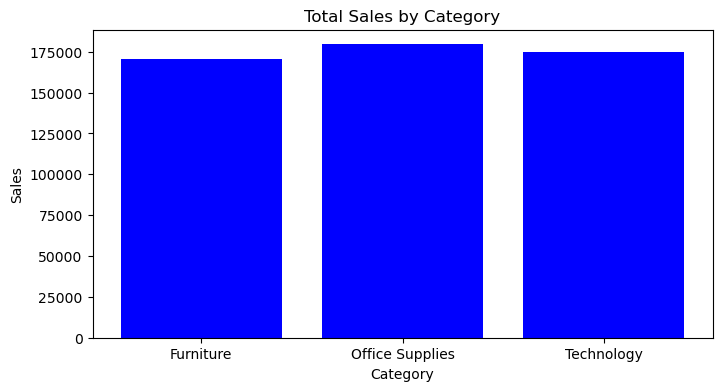

In [45]:
category_sales = df.groupby("Category")["Sales"].sum()
plt.figure(figsize=(8,4))
plt.bar(category_sales.index,category_sales.values,color="blue")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

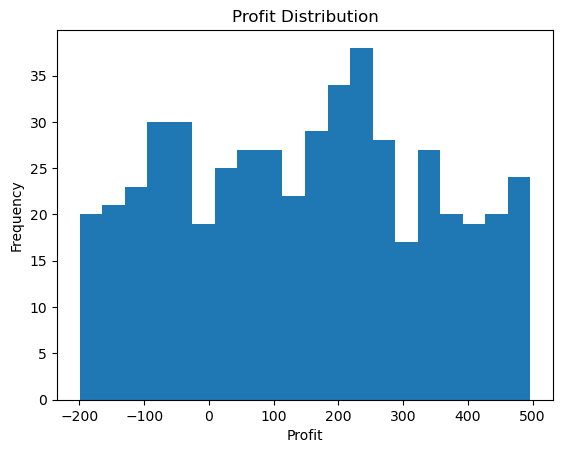

In [46]:
df["Profit"].plot(kind="hist", bins=20)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.show()

OBSERVATIONS:

1. The business generates sales almost equally across Furniture, Office Supplies, and Technology, indicating a balanced revenue distribution.

2. The Central region produces the highest average profit, while the East region generates the lowest, showing regional performance differences.

3. Among sub-categories, Chairs and Storage contribute the most to profit, whereas Phones generate the least profit.

4. The profit distribution includes both positive and negative values, meaning some transactions result in losses.

5. Most profit values are concentrated on the positive side, indicating that overall the business is profitable despite some losses.
